In [1]:
import pandas as pd
patients = pd.read_csv("../data/data_clinical_patient.txt", sep="\t", skiprows=4)
patients.head()

,PATIENT_ID,STUDY,BCR_STATUS,HISTOLOGICAL_DIAGNOSIS,AGE,SEX,OS_MONTHS,OS_STATUS,KARNOFSKY_PERFORMANCE_SCORE
0,TCGA-CS-4938,Brain Lower Grade Glioma,IGC,astrocytoma,31.0,Female,4.7,0:LIVING,90.0
1,TCGA-CS-4941,Brain Lower Grade Glioma,IGC,astrocytoma,67.0,Male,7.7,1:DECEASED,90.0
2,TCGA-CS-4942,Brain Lower Grade Glioma,IGC,astrocytoma,44.0,Female,43.9,1:DECEASED,90.0
3,TCGA-CS-4943,Brain Lower Grade Glioma,IGC,astrocytoma,37.0,Male,18.1,0:LIVING,50.0
4,TCGA-CS-4944,Brain Lower Grade Glioma,IGC,astrocytoma,50.0,Male,10.6,0:LIVING,90.0


In [2]:
patients.shape

(1122, 9)

In [3]:
samples = pd.read_csv("../data/data_clinical_sample.txt", sep="\t", skiprows=4)
samples.shape

(1122, 48)

In [4]:
data = patients.merge(samples, on="PATIENT_ID", how="inner")
data.shape

(1122, 56)

In [5]:
pd.crosstab(data["IDH_STATUS"], data["GRADE"])

GRADE,G2,G3,G4
IDH_STATUS,,,
Mutant,195,174,37
WT,19,67,434


In [6]:
data["IDH_STATUS"].isna().sum()
data["GRADE"].isna().sum()
pd.crosstab(data["IDH_STATUS"].isna(), data["HISTOLOGICAL_DIAGNOSIS"])

HISTOLOGICAL_DIAGNOSIS,astrocytoma,glioblastoma,oligoastrocytoma,oligodendroglioma
IDH_STATUS,,,,
False,168,471,114,173
True,1,119,0,1


In [7]:
data["OS_STATUS"].value_counts()

OS_STATUS
1:DECEASED    524
0:LIVING      522
Name: count, dtype: int64

In [8]:
pd.crosstab(data["IDH_STATUS"], data["OS_STATUS"])

OS_STATUS,0:LIVING,1:DECEASED
IDH_STATUS,,
Mutant,337,69
WT,169,350


In [9]:
data.groupby(["IDH_STATUS", "OS_STATUS"])["OS_MONTHS"].median()

IDH_STATUS  OS_STATUS 
Mutant      0:LIVING      14.2
            1:DECEASED    41.1
WT          0:LIVING       8.4
            1:DECEASED    11.1
Name: OS_MONTHS, dtype: float64

In [10]:
pd.crosstab(data["GRADE"].isna(), data["HISTOLOGICAL_DIAGNOSIS"])

HISTOLOGICAL_DIAGNOSIS,astrocytoma,glioblastoma,oligoastrocytoma,oligodendroglioma
GRADE,,,,
False,169,590,114,174


In [11]:
data[data["OS_STATUS"].isna()][["HISTOLOGICAL_DIAGNOSIS", "GRADE", "IDH_STATUS", "AGE"]].head(20)

,HISTOLOGICAL_DIAGNOSIS,GRADE,IDH_STATUS,AGE
153,NaN,NaN,NaN,NaN
164,NaN,NaN,WT,NaN
165,NaN,NaN,Mutant,NaN
166,NaN,NaN,Mutant,NaN
167,NaN,NaN,Mutant,NaN
168,NaN,NaN,WT,NaN
169,NaN,NaN,Mutant,NaN
170,NaN,NaN,WT,NaN
171,NaN,NaN,WT,NaN
172,NaN,NaN,WT,NaN


In [12]:
data.groupby("IDH_STATUS")["AGE"].describe()

,count,mean,std,min,25%,50%,75%,max
IDH_STATUS,,,,,,,,
Mutant,406.0,40.963054,12.432181,14.0,31.0,39.0,50.0,75.0
WT,520.0,58.798077,13.444082,18.0,51.0,59.0,68.0,89.0


In [13]:
pd.crosstab(data["HISTOLOGICAL_DIAGNOSIS"], data["GRADE"])

GRADE,G2,G3,G4
HISTOLOGICAL_DIAGNOSIS,,,
astrocytoma,55,114,0
glioblastoma,0,0,590
oligoastrocytoma,61,53,0
oligodendroglioma,100,74,0


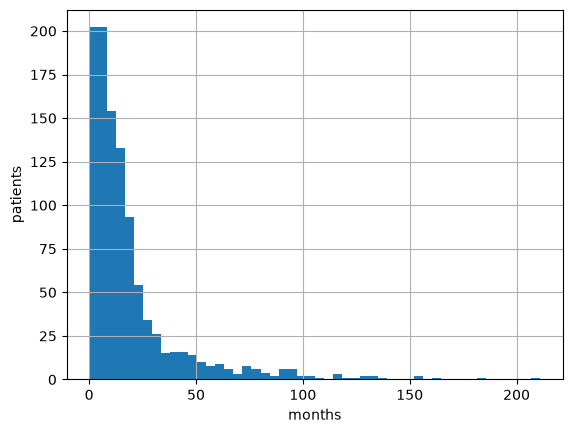

In [14]:
import matplotlib.pyplot as plt
data["OS_MONTHS"].hist(bins=50)
plt.xlabel("months")
plt.ylabel("patients")
plt.show()

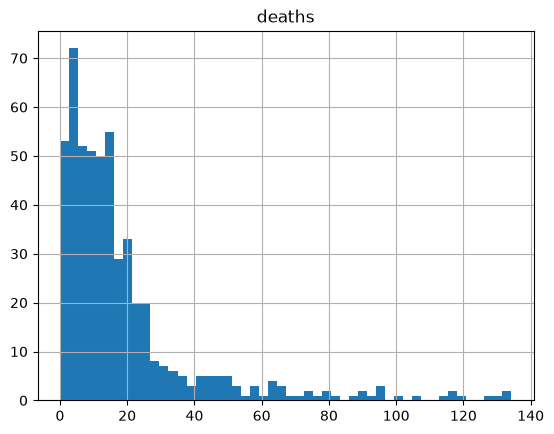

In [15]:
data[data["OS_STATUS"] == "1:DECEASED"]["OS_MONTHS"].hist(bins=50)
plt.title("deaths")
plt.show()

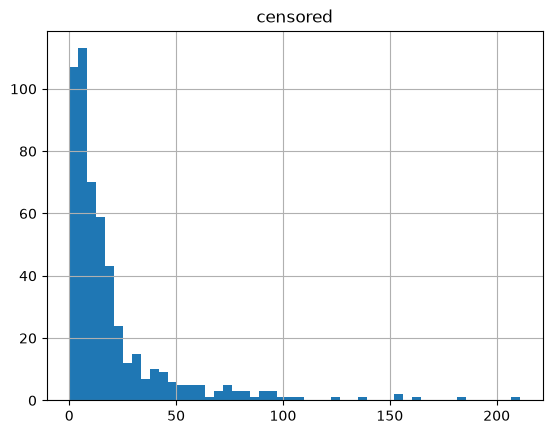

In [16]:
data[data["OS_STATUS"] == "0:LIVING"]["OS_MONTHS"].hist(bins=50)
plt.title("censored")
plt.show()

In [17]:
data.groupby(["IDH_STATUS", "GRADE", "OS_STATUS"])["OS_MONTHS"].median()

IDH_STATUS  GRADE  OS_STATUS 
Mutant      G2     0:LIVING      15.00
                   1:DECEASED    49.00
            G3     0:LIVING      11.10
                   1:DECEASED    43.95
            G4     0:LIVING      10.40
                   1:DECEASED    29.10
WT          G2     0:LIVING       3.80
                   1:DECEASED    16.20
            G3     0:LIVING      10.80
                   1:DECEASED    10.35
            G4     0:LIVING       8.30
                   1:DECEASED    11.10
Name: OS_MONTHS, dtype: float64

In [18]:
data.groupby(["IDH_STATUS", "GRADE", "OS_STATUS"])["OS_MONTHS"].count()

IDH_STATUS  GRADE  OS_STATUS 
Mutant      G2     0:LIVING      176
                   1:DECEASED     19
            G3     0:LIVING      146
                   1:DECEASED     28
            G4     0:LIVING       15
                   1:DECEASED     22
WT          G2     0:LIVING       17
                   1:DECEASED      2
            G3     0:LIVING       37
                   1:DECEASED     30
            G4     0:LIVING      115
                   1:DECEASED    318
Name: OS_MONTHS, dtype: int64

In [19]:
data[(data["IDH_STATUS"] == "Mutant") & (data["OS_STATUS"] == "0:LIVING")]["OS_MONTHS"].describe()

count    337.000000
mean      22.783086
std       28.412975
min        0.000000
25%        5.700000
50%       14.200000
75%       27.000000
max      182.200000
Name: OS_MONTHS, dtype: float64

In [20]:
data[(data["IDH_STATUS"] == "Mutant") & (data["OS_STATUS"] == "1:DECEASED")]["OS_MONTHS"].describe()

count     69.000000
mean      48.085507
std       33.446099
min        0.200000
25%       22.400000
50%       41.100000
75%       67.400000
max      134.200000
Name: OS_MONTHS, dtype: float64

In [21]:
(data["OS_MONTHS"] == 0).sum()

np.int64(6)

In [22]:
data["event"] = (data["OS_STATUS"] == "1:DECEASED").astype(int)

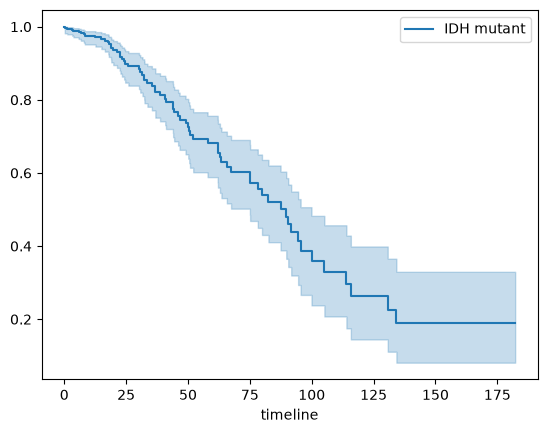

In [25]:
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
mutant = km_data[km_data["IDH_STATUS"] == "Mutant"]
kmf.fit(mutant["OS_MONTHS"], mutant["event"], label="IDH mutant")
kmf.plot_survival_function()
plt.show()

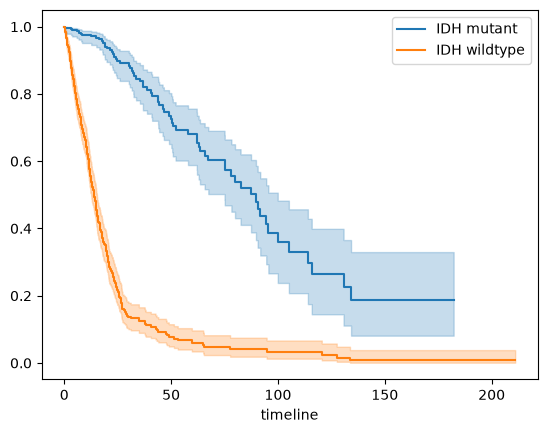

In [26]:
fig, ax = plt.subplots()

mutant = km_data[km_data["IDH_STATUS"] == "Mutant"]
kmf_m = KaplanMeierFitter()
kmf_m.fit(mutant["OS_MONTHS"], mutant["event"], label="IDH mutant")
kmf_m.plot_survival_function(ax=ax)

wt = km_data[km_data["IDH_STATUS"] == "WT"]
kmf_w = KaplanMeierFitter()
kmf_w.fit(wt["OS_MONTHS"], wt["event"], label="IDH wildtype")
kmf_w.plot_survival_function(ax=ax)

plt.show()

In [27]:
print(kmf_m.median_survival_time_)
print(kmf_w.median_survival_time_)

89.7
14.0


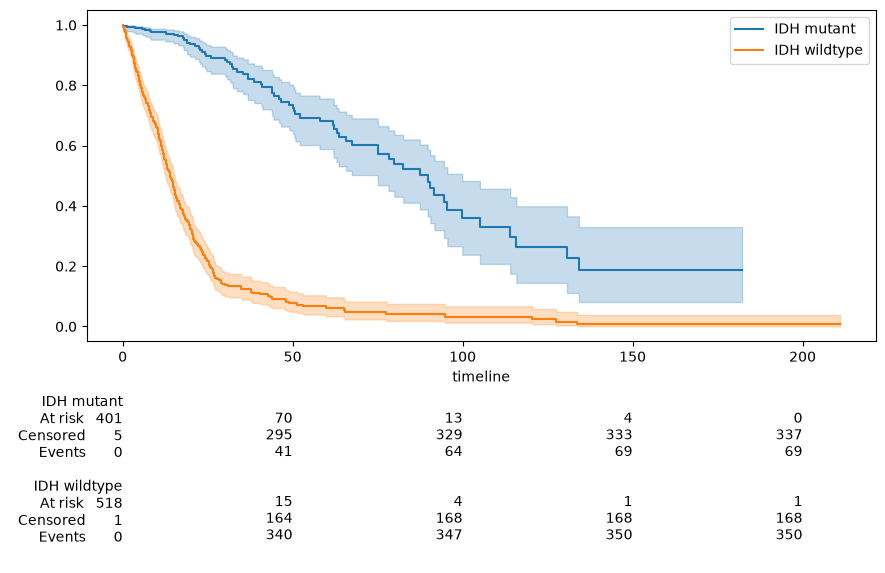

In [29]:
from lifelines.plotting import add_at_risk_counts

fig, ax = plt.subplots(figsize=(9, 6))
kmf_m.plot_survival_function(ax=ax)
kmf_w.plot_survival_function(ax=ax)
add_at_risk_counts(kmf_m, kmf_w, ax=ax)
plt.tight_layout()
plt.show()

In [30]:
m_median = kmf_m.median_survival_time_
w_median = kmf_w.median_survival_time_
print("mutant median:", m_median)
print("wt median:", w_median)

print("mutant at risk at its median:", kmf_m.event_table.loc[:m_median, "at_risk"].iloc[-1])
print("wt at risk at its median:", kmf_w.event_table.loc[:w_median, "at_risk"].iloc[-1])

mutant median: 89.7
wt median: 14.0
mutant at risk at its median: 24
wt at risk at its median: 180


In [32]:
from lifelines.utils import median_survival_times
print(median_survival_times(kmf_m.confidence_interval_))
print(median_survival_times(kmf_w.confidence_interval_))

     IDH mutant_lower_0.95  IDH mutant_upper_0.95
0.5                   75.0                   99.9
     IDH wildtype_lower_0.95  IDH wildtype_upper_0.95
0.5                     12.6                     15.3


In [33]:
from lifelines.statistics import logrank_test

result = logrank_test(mutant["OS_MONTHS"], wt["OS_MONTHS"],
                      mutant["event"], wt["event"])
result.print_summary()